In [1]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt 
import matplotlib as mpl
import seaborn as sns
import plotly.express as px
import copy
import kagglehub
import os
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

print("Módulos y clases importados")

Módulos y clases importados


In [2]:
# 1. CARGA DE DATOS
path_folder = kagglehub.dataset_download("waddahali/2026-intelligence-economy-labor-vs-ai-compute")
ruta_csv = os.path.join(path_folder, "labor_substitution.csv")

dfOriginal = pd.read_csv(ruta_csv)
dataframe = copy.deepcopy(dfOriginal)

# Declaración de variables operativas
variable_dependiente_Y = 'Substitution_Year_Est'
variables_analisis = ['Automation_Risk_Index', 'Agent_Labor_Equivalent_Cost', 'Human_Labor_Cost_hr', 'Industry']

In [3]:
# 2. EXPLORACIÓN DE DATOS INICIALES 
print("========================================")
print("    EXPLORACIÓN DE DATOS INICIALES")
print("========================================")

# Tamaño: Cantidad de observaciones y variables 
print(f'Cantidad de observaciones (roles): {dataframe.shape[0]}')
print(f'Cantidad de variables: {dataframe.shape[1]}')

# Visualización preliminar
print("\n--- Muestra de datos ---")
print(dataframe.tail())

# Tipos de variables y estructura
print("\n--- Tipos de variables ---")
dataframe.info()

# Calidad de los datos: Valores faltantes y duplicados 
print("\n--- Valores faltantes por columna ---")
print(dataframe.isnull().sum())

cantidad_duplicados = dataframe.duplicated().sum()
print(f"\nCantidad de registros duplicados: {cantidad_duplicados}")

# Detección inicial de atípicos (Outliers) mediante descripción rápida 
print("\n--- Inspección de Atípicos (Resumen descriptivo) ---")
print(dataframe.describe())

    EXPLORACIÓN DE DATOS INICIALES
Cantidad de observaciones (roles): 1200
Cantidad de variables: 12

--- Muestra de datos ---
      Role_ID Industry  Human_Labor_Cost_hr  Tokens_per_Human_Hour  \
1195  TEL-076  Telecom                  104                 225111   
1196  TEL-077  Telecom                  121                 307699   
1197  TEL-078  Telecom                   42                  82049   
1198  TEL-079  Telecom                   41                  80723   
1199  TEL-080  Telecom                   96                 176160   

      Inference_Cost_2026  Agent_Labor_Equivalent_Cost  \
1195               0.0335                       0.0075   
1196               0.3213                       0.0989   
1197               0.1063                       0.0087   
1198               0.2097                       0.0169   
1199               0.7330                       0.1291   

      Substitution_Elasticity  AI_Augmentation_Factor  Automation_Risk_Index  \
1195                   

In [4]:
# 3. RESUMEN ESTADÍSTICO
print("========================================")
print("    RESUMEN ESTADÍSTICO")
print("========================================")

columnas_numericas = ['Automation_Risk_Index', 'Agent_Labor_Equivalent_Cost', 'Human_Labor_Cost_hr', variable_dependiente_Y]

print("\n--- Estadísticas de Variables Numéricas Clave ---")
print(dataframe[columnas_numericas].describe())

    RESUMEN ESTADÍSTICO

--- Estadísticas de Variables Numéricas Clave ---
       Automation_Risk_Index  Agent_Labor_Equivalent_Cost  \
count             1200.00000                  1200.000000   
mean                96.54500                     0.056904   
std                 11.53844                     0.058584   
min                 11.00000                     0.000700   
25%                100.00000                     0.015575   
50%                100.00000                     0.036300   
75%                100.00000                     0.075325   
max                100.00000                     0.374100   

       Human_Labor_Cost_hr  Substitution_Year_Est  
count          1200.000000            1200.000000  
mean             79.266667            2028.941667  
std              38.768390               1.756655  
min              20.000000            2026.000000  
25%              50.000000            2028.000000  
50%              71.000000            2029.000000  
75%        

### Conclusiones

#### 1. Índice de Riesgo de Automatización (`Automation_Risk_Index`)
* **Asimetría extrema negativa:** El percentil 25, la mediana (50%) y el percentil 75 convergen en el valor máximo absoluto de 100.
* **Saturación de vulnerabilidad:** Más del 75% de los 1200 roles evaluados presentan un riesgo inminente y total de automatización.
* **Dispersión residual:** La desviación estándar (11.53) y la media geométrica aparente (96.54) están arrastradas hacia abajo exclusivamente por un clúster minoritario de valores atípicos de bajo riesgo (mínimo de 11.0).

#### 2. Costo Equivalente de Agente IA (`Agent_Labor_Equivalent_Cost`)
* **Asimetría positiva:** La media (0.0569) es superior a la mediana (0.0363), indicando una alta concentración de frecuencias en el umbral inferior de costos.
* **Varianza relativa severa:** La desviación estándar (0.0585) supera a la media. La mayoría de los agentes operan a fracciones de centavo, pero existen requerimientos computacionales específicos que elevan el costo (máximo de 0.3741).
* **Barrera económica nula:** El 75% de la muestra reporta un costo equivalente igual o inferior a 0.0753 USD. 

#### 3. Costo de Trabajo Humano por Hora (`Human_Labor_Cost_hr`)
* **Concentración de masa salarial:** El 50% central de los roles analizados (rango intercuartílico) presenta costos por hora entre 50.00 USD y 103.00 USD. La mediana base se sitúa en 71.00 USD.
* **Asimetría por alta especialización:** La media (79.26 USD) es arrastrada por encima de la mediana debido a un segmento de roles de alto valor económico que alcanzan un máximo de 233.00 USD por hora.
* **Disparidad competitiva absoluta:** El costo laboral humano mínimo registrado (20.00 USD/hr) es más de 53 veces superior al costo operativo máximo de un agente de IA (0.3741 USD/hr). El diferencial de rentabilidad justifica la erradicación financiera del estrato humano en todos los niveles operativos.

#### 4. Año Estimado de Sustitución (`Substitution_Year_Est`)
* **Transición sistémica a corto plazo:** El 50% de las ocupaciones (mediana) enfrenta la sustitución tecnológica para el año 2029.
* **Alta densidad temporal:** La desviación estándar restringida (1.75 años) evidencia un choque de automatización simultáneo, refutando modelos de adopción gradual.
* **Rango intercuartílico crítico:** El 50% central de la fuerza laboral representada será sustituida en una ventana estricta de 24 meses, comprendida entre 2028 y 2030.

    VISUALIZACIÓN Y ANÁLISIS DE DATOS


C:\Users\user\AppData\Local\Temp\ipykernel_27948\1547729628.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataframe, x='Industry', y='Substitution_Year_Est', palette='Set3')


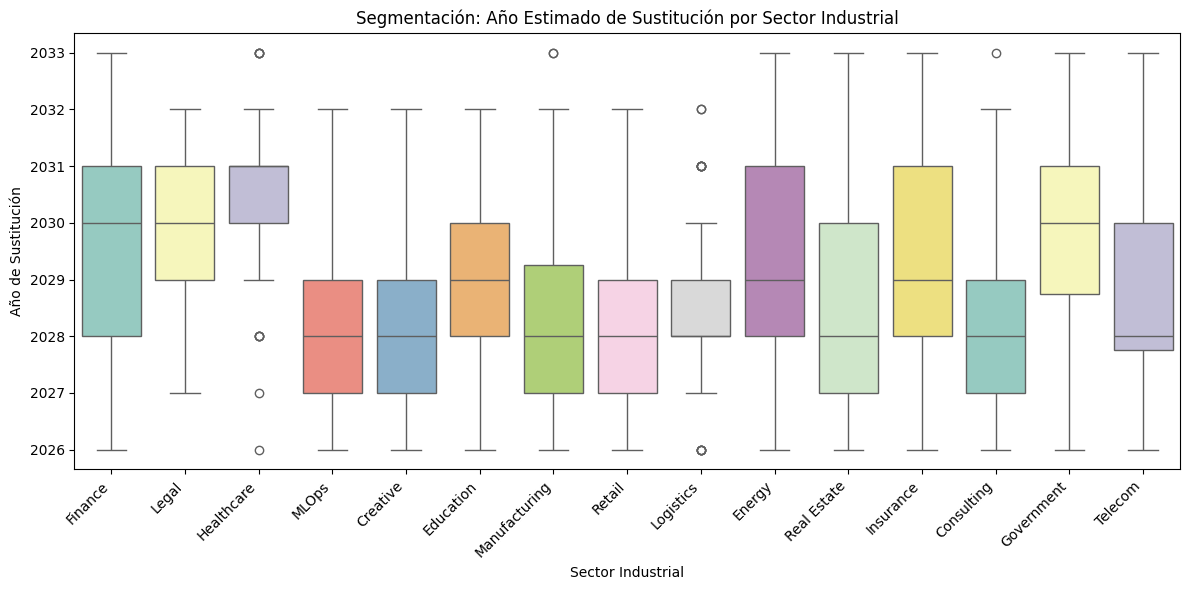

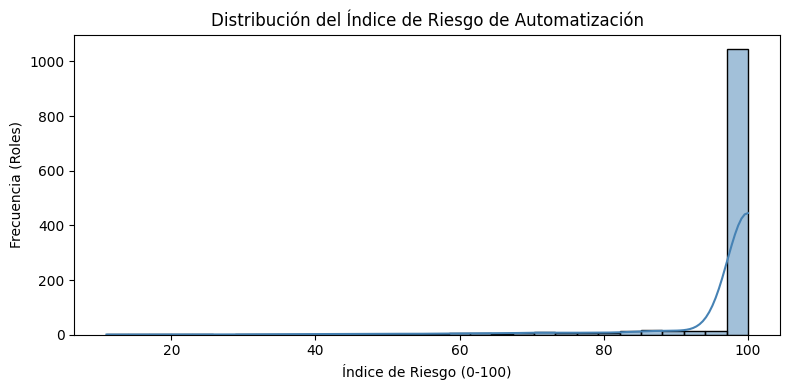

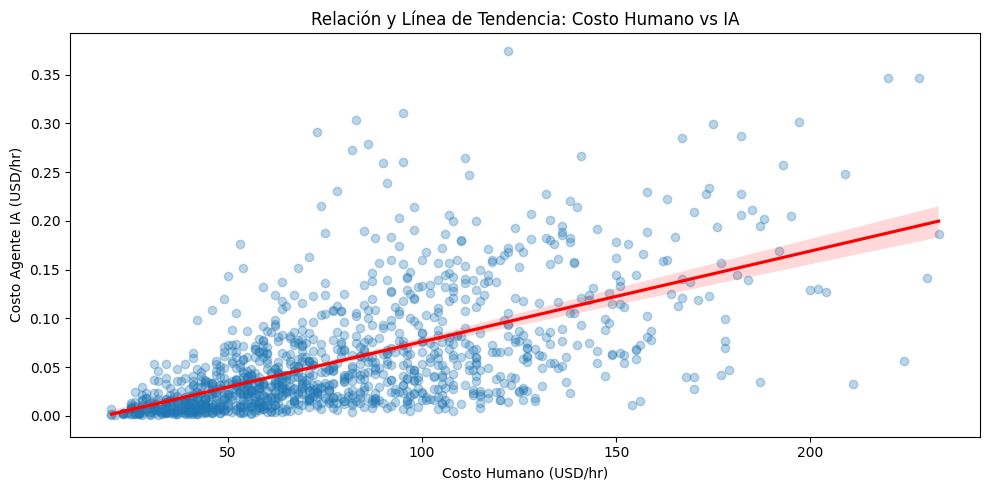

In [5]:
# 4. VISUALIZACIÓN DE DATOS
print("========================================")
print("    VISUALIZACIÓN Y ANÁLISIS DE DATOS")
print("========================================")

# 4.1 Segmentación: Año de Sustitución por Sector (Fase 9 de la Guía / Sugerencia Kaggle)
# Usamos un Boxplot para ver la dispersión del año de reemplazo en cada industria
plt.figure(figsize=(12, 6))
sns.boxplot(data=dataframe, x='Industry', y='Substitution_Year_Est', palette='Set3')
plt.title('Segmentación: Año Estimado de Sustitución por Sector Industrial')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Sector Industrial')
plt.ylabel('Año de Sustitución')
plt.tight_layout()
plt.show()

# 4.2 Histograma: Distribución del Riesgo de Automatización
plt.figure(figsize=(8, 4))
sns.histplot(dataframe['Automation_Risk_Index'], bins=30, kde=True, color='steelblue')
plt.title('Distribución del Índice de Riesgo de Automatización')
plt.xlabel('Índice de Riesgo (0-100)')
plt.ylabel('Frecuencia (Roles)')
plt.tight_layout()
plt.show()

# 4.3 Comparativa de Costos (Relación Bivariada Final)
plt.figure(figsize=(10, 5))
sns.regplot(data=dataframe, x='Human_Labor_Cost_hr', y='Agent_Labor_Equivalent_Cost', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relación y Línea de Tendencia: Costo Humano vs IA')
plt.xlabel('Costo Humano (USD/hr)')
plt.ylabel('Costo Agente IA (USD/hr)')
plt.tight_layout()
plt.show()

In [6]:
# --- 5. ANÁLISIS DE VARIABLES CATEGÓRICAS ---
print("========================================")
print("    ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("========================================")

# Definición de variables categóricas de interés
variables_categoricas = ['Industry', 'Regulatory_Moat']

for col in variables_categoricas:
    print(f"\n--- Análisis de frecuencia: {col} ---")
    
    # Frecuencia absoluta (conteo)
    conteo = dataframe[col].value_counts()
    
    # Frecuencia relativa (porcentaje)
    porcentaje = dataframe[col].value_counts(normalize=True) * 100
    
    # Creación de un resumen para visualización limpia
    resumen = pd.DataFrame({
        'Cantidad': conteo,
        'Porcentaje (%)': porcentaje.round(2)
    })
    
    print(resumen)

print(f"\nCantidad total de variables categóricas analizadas: {len(variables_categoricas)}")

    ANÁLISIS DE VARIABLES CATEGÓRICAS

--- Análisis de frecuencia: Industry ---
               Cantidad  Porcentaje (%)
Industry                               
Finance              80            6.67
Legal                80            6.67
Healthcare           80            6.67
MLOps                80            6.67
Creative             80            6.67
Education            80            6.67
Manufacturing        80            6.67
Retail               80            6.67
Logistics            80            6.67
Energy               80            6.67
Real Estate          80            6.67
Insurance            80            6.67
Consulting           80            6.67
Government           80            6.67
Telecom              80            6.67

--- Análisis de frecuencia: Regulatory_Moat ---
                 Cantidad  Porcentaje (%)
Regulatory_Moat                          
High                  420           35.00
Med                   398           33.17
Low                   3

    ANÁLISIS DE CORRELACIÓN

--- Matriz de Correlación ---
                             Automation_Risk_Index  \
Automation_Risk_Index                     1.000000   
Agent_Labor_Equivalent_Cost              -0.619490   
Human_Labor_Cost_hr                      -0.080895   
Substitution_Year_Est                    -0.023942   

                             Agent_Labor_Equivalent_Cost  Human_Labor_Cost_hr  \
Automation_Risk_Index                          -0.619490            -0.080895   
Agent_Labor_Equivalent_Cost                     1.000000             0.615205   
Human_Labor_Cost_hr                             0.615205             1.000000   
Substitution_Year_Est                           0.062815             0.105537   

                             Substitution_Year_Est  
Automation_Risk_Index                    -0.023942  
Agent_Labor_Equivalent_Cost               0.062815  
Human_Labor_Cost_hr                       0.105537  
Substitution_Year_Est                     1.000000  

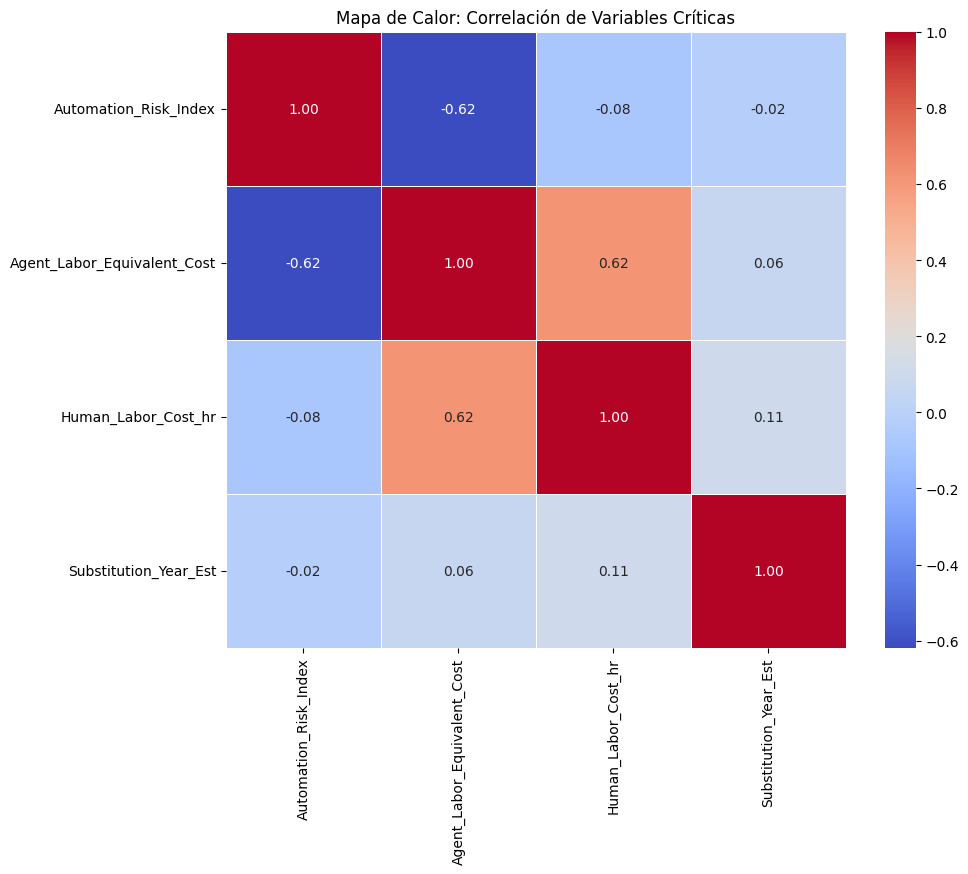

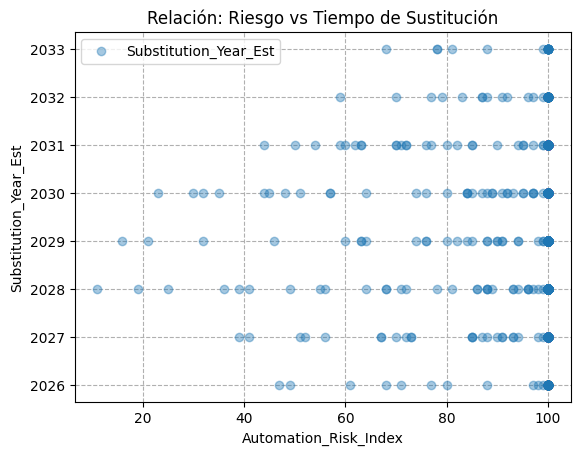

In [7]:
# --- 6. ANÁLISIS DE CORRELACIÓN ---
print("========================================")
print("    ANÁLISIS DE CORRELACIÓN")
print("========================================")

# 6.1 Matriz de Correlación Numérica
columnas_interes = ['Automation_Risk_Index', 'Agent_Labor_Equivalent_Cost', 
                    'Human_Labor_Cost_hr', 'Substitution_Year_Est']
matriz_corr = dataframe[columnas_interes].corr()

print("\n--- Matriz de Correlación ---")
print(matriz_corr)

# 6.2 Mapa de Calor (Heatmap) 
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlación de Variables Críticas')
plt.show()


# 6.3 Gráfico de Dispersión (Estilo docente celda 41)
# Visualización específica de la relación más fuerte detectada
dataframe.plot(x='Automation_Risk_Index', y='Substitution_Year_Est', style='o', alpha=0.4)
plt.title('Relación: Riesgo vs Tiempo de Sustitución')
plt.xlabel('Automation_Risk_Index')
plt.ylabel('Substitution_Year_Est')
plt.grid(True, linestyle='--')
plt.show()

    LIMPIEZA Y PREPARACIÓN DE DATOS
Variable 'Role_ID' eliminada.
Dimensiones tras limpieza: (1200, 11)


C:\Users\user\AppData\Local\Temp\ipykernel_27948\2336837198.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=Y, palette='viridis')


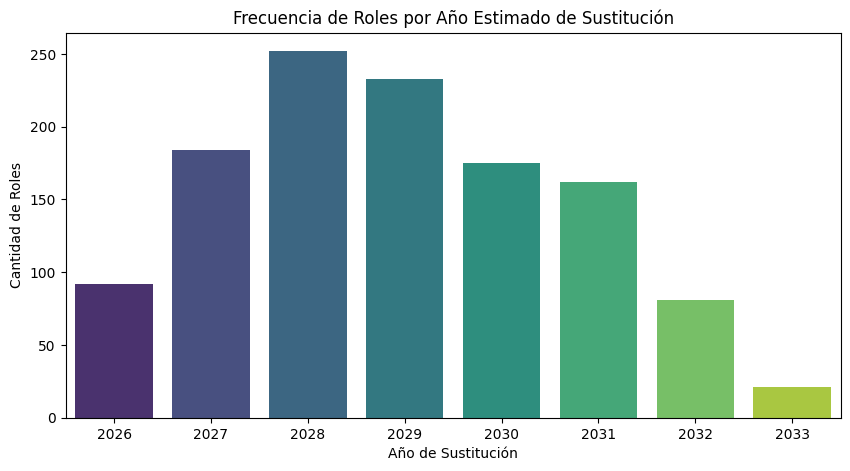


--- Primeros registros del dataframe procesado ---
  Industry  Human_Labor_Cost_hr  Tokens_per_Human_Hour  Inference_Cost_2026  \
0  Finance                  114                 231710               0.5570   
1  Finance                   97                 199855               0.1045   
2  Finance                   58                  83259               0.4215   
3  Finance                   73                 165341               0.1999   
4  Finance                  100                 187993               0.4529   

   Agent_Labor_Equivalent_Cost  Substitution_Elasticity  \
0                       0.1291                     0.84   
1                       0.0209                     1.04   
2                       0.0351                     0.89   
3                       0.0331                     1.03   
4                       0.0851                     0.37   

   AI_Augmentation_Factor  Automation_Risk_Index  Hardware_CapEx_Sensitivity  \
0                    0.80             

In [8]:
# --- 7. MANEJO DE DATOS FALTANTES Y VARIABLES NO RELEVANTES ---
print("========================================")
print("    LIMPIEZA Y PREPARACIÓN DE DATOS")
print("========================================")

# 7.1 Eliminación de variables no relevantes (Identificadores)
# Role_ID es un registro único que no aporta patrones al análisis estadístico
if 'Role_ID' in dataframe.columns:
    dataframe = dataframe.drop(['Role_ID'], axis=1)
    print("Variable 'Role_ID' eliminada.")

# 7.2 Verificación y manejo de datos faltantes
# Como se observó en la Fase 2, el dataset no presenta nulos. 
# Procedemos a confirmar la limpieza final.
dataframe = dataframe.dropna()
print(f"Dimensiones tras limpieza: {dataframe.shape}")

# 7.3 Visualización de la Variable Objetivo (Y)
plt.figure(figsize=(10, 5))
Y = dataframe[variable_dependiente_Y]
sns.countplot(x=Y, palette='viridis')
plt.title('Frecuencia de Roles por Año Estimado de Sustitución')
plt.xlabel('Año de Sustitución')
plt.ylabel('Cantidad de Roles')
plt.show()

print("\n--- Primeros registros del dataframe procesado ---")
print(dataframe.head())

    SEGMENTACIÓN DE DATOS

--- Impacto Promedio por Sector Industrial ---
               Automation_Risk_Index  Substitution_Year_Est  \
Industry                                                      
Retail                       99.6625              2028.0500   
Creative                     76.5500              2028.0875   
Consulting                   98.3750              2028.2250   
MLOps                       100.0000              2028.4000   
Manufacturing                99.4375              2028.4750   
Logistics                    99.8875              2028.5250   
Telecom                      98.8250              2028.5750   
Education                    97.5625              2028.6875   
Real Estate                 100.0000              2028.7875   
Insurance                    98.1625              2029.1875   
Energy                       96.3875              2029.4500   
Finance                      96.9500              2029.6500   
Government                   99.3625        

C:\Users\user\AppData\Local\Temp\ipykernel_27948\190765837.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dataframe, x='Industry', y='Automation_Risk_Index', palette='coolwarm')


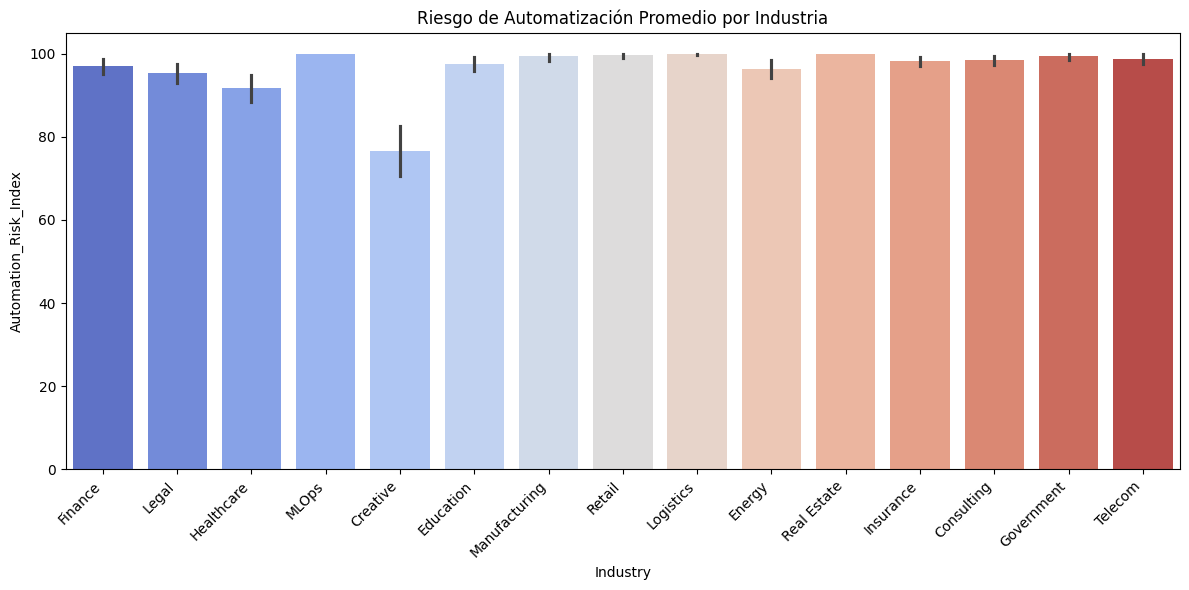

In [9]:
# --- 8. SEGMENTACIÓN DE DATOS ---
print("========================================")
print("    SEGMENTACIÓN DE DATOS")
print("========================================")

# Agrupación por industria para comparar métricas críticas
# Se utiliza la media para identificar la tendencia central de cada sector
analisis_sectorial = dataframe.groupby('Industry').agg({
    'Automation_Risk_Index': 'mean',
    'Substitution_Year_Est': 'mean',
    'Human_Labor_Cost_hr': 'mean'
}).sort_values(by='Substitution_Year_Est')

print("\n--- Impacto Promedio por Sector Industrial ---")
print(analisis_sectorial)

# Visualización de segmentación (Estilo docente)
plt.figure(figsize=(12, 6))
sns.barplot(data=dataframe, x='Industry', y='Automation_Risk_Index', palette='coolwarm')
plt.title('Riesgo de Automatización Promedio por Industria')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# --- 9. GENERACIÓN DE HIPÓTESIS ---
print("========================================")
print("    GENERACIÓN DE HIPÓTESIS")
print("========================================")

# Formulación de hipótesis basadas en el análisis exploratorio previo
hipotesis = [
    "H1: Existe una correlación negativa fuerte entre Automation_Risk_Index y Substitution_Year_Est; a mayor riesgo técnico, menor es el tiempo de permanencia del rol humano.",
    "H2: Los sectores industriales con Human_Labor_Cost_hr superior a 100 USD presentan una ventana de sustitución más agresiva (previa a 2028) debido al incentivo de ahorro operativo.",
    "H3: La saturación del Automation_Risk_Index en 100 para más del 75% de la muestra indica que la barrera de sustitución ya no es técnica, sino económica o regulatoria.",
    "H4: El Agent_Labor_Equivalent_Cost actúa como un piso financiero que garantiza la viabilidad de la IA en todos los estratos salariales analizados."
]

for i, h in enumerate(hipotesis, 1):
    print(f"{i}. {h}")

    GENERACIÓN DE HIPÓTESIS
1. H1: Existe una correlación negativa fuerte entre Automation_Risk_Index y Substitution_Year_Est; a mayor riesgo técnico, menor es el tiempo de permanencia del rol humano.
2. H2: Los sectores industriales con Human_Labor_Cost_hr superior a 100 USD presentan una ventana de sustitución más agresiva (previa a 2028) debido al incentivo de ahorro operativo.
3. H3: La saturación del Automation_Risk_Index en 100 para más del 75% de la muestra indica que la barrera de sustitución ya no es técnica, sino económica o regulatoria.
4. H4: El Agent_Labor_Equivalent_Cost actúa como un piso financiero que garantiza la viabilidad de la IA en todos los estratos salariales analizados.
